# Assignment 2: Variational Autoencoders for Remote Sensing


In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

# Hyper-parameters
image_size = 64
z_dim = 32
num_epochs = 40  # Increased for better convergence
batch_size = 128
learning_rate = 1e-3
beta = 0.2  # Beta-VAE hyperparameter to prioritize reconstruction quality


Using device: mps


In [2]:
# Dataset Preparation
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
])

# Downloading EuroSAT
dataset_dir = './data'
print("Loading EuroSAT dataset...")
try:
    dataset = datasets.EuroSAT(root=dataset_dir, download=True, transform=transform)
except Exception as e:
    print(f"Error downloading EuroSAT via torchvision: {e}")
    print("Falling back to downloading via wget...")
    import urllib.request
    import zipfile
    import ssl
    ssl._create_default_https_context = ssl._create_unverified_context
    url = "https://madm.dfki.de/files/sentinel/EuroSAT.zip"
    os.makedirs(dataset_dir, exist_ok=True)
    zip_path = os.path.join(dataset_dir, "EuroSAT.zip")
    if not os.path.exists(zip_path):
        urllib.request.urlretrieve(url, zip_path)
    if not os.path.exists(os.path.join(dataset_dir, "2750")):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(dataset_dir)
    dataset = datasets.ImageFolder(root=os.path.join(dataset_dir, "2750"), transform=transform)

data_loader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True, drop_last=True)
print(f"Dataset Size: {len(dataset)}")
print(f"Classes: {dataset.classes}")


Loading EuroSAT dataset...
Dataset Size: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## Task 1: Architectural Design


In [3]:
# Improved VAE Architecture
class VAE(nn.Module):
    def __init__(self, image_channels=3, z_dim=32):
        super(VAE, self).__init__()
        
        # Encoder (Convolutional)
        self.encoder = nn.Sequential(
            nn.Conv2d(image_channels, 32, kernel_size=4, stride=2, padding=1), # 32x32
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),             # 16x16
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),            # 8x8
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),           # 4x4
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),           # 2x2
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
            nn.Flatten()                                                       # 512 * 2 * 2 = 2048
        )
        
        self.fc_mean = nn.Linear(2048, z_dim)
        self.fc_logvar = nn.Linear(2048, z_dim)
        
        # Decoder (Transposed Convolutional)
        self.fc_decode = nn.Linear(z_dim, 2048)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),  # 4x4
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # 8x8
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   # 16x16
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),    # 32x32
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32, image_channels, kernel_size=4, stride=2, padding=1), # 64x64
            nn.Sigmoid() # Output values between 0 and 1
        )
        
    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mean(h), self.fc_logvar(h)
    
    def reparameterize(self, mean, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mean + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(-1, 512, 2, 2)
        return self.decoder(h)
    
    def forward(self, x):
        mean, log_var = self.encode(x)
        z = self.reparameterize(mean, log_var)
        out = self.decode(z)
        return out, mean, log_var

model = VAE(image_channels=3, z_dim=z_dim).to(device)
print(model)


VAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2)
    (11): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (12): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): LeakyReLU(negative_slope=0.2)
    (14): Flatten(start_dim=1, en

## Task 2: Training and Loss Function


In [4]:
# Loss Function and Optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

def vae_loss(recon_x, x, mean, log_var, beta=1.0):
    # Reconstruction Loss (MSE)
    RECON = F.mse_loss(recon_x, x, reduction='sum')
    
    # Kullback-Leibler Divergence
    KLD = -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())
    
    return RECON + beta * KLD, RECON, KLD


Starting Training for 40 Epochs with Beta=0.2...


Epoch [1/40], Loss: 17714.1287 (Recon: 112.5069, KLD: 88008.1063)


Epoch [5/40], Loss: 64.5749 (Recon: 57.3728, KLD: 36.0102)


Epoch [10/40], Loss: 61.5147 (Recon: 54.2219, KLD: 36.4640)


Epoch [15/40], Loss: 60.4647 (Recon: 53.2625, KLD: 36.0107)


Epoch [20/40], Loss: 58.9930 (Recon: 51.8283, KLD: 35.8234)


Epoch [25/40], Loss: 58.8188 (Recon: 51.6487, KLD: 35.8506)


Epoch [30/40], Loss: 57.8516 (Recon: 50.6674, KLD: 35.9207)


Epoch [35/40], Loss: 57.6709 (Recon: 50.4858, KLD: 35.9254)


Epoch [40/40], Loss: 56.4097 (Recon: 49.2158, KLD: 35.9696)


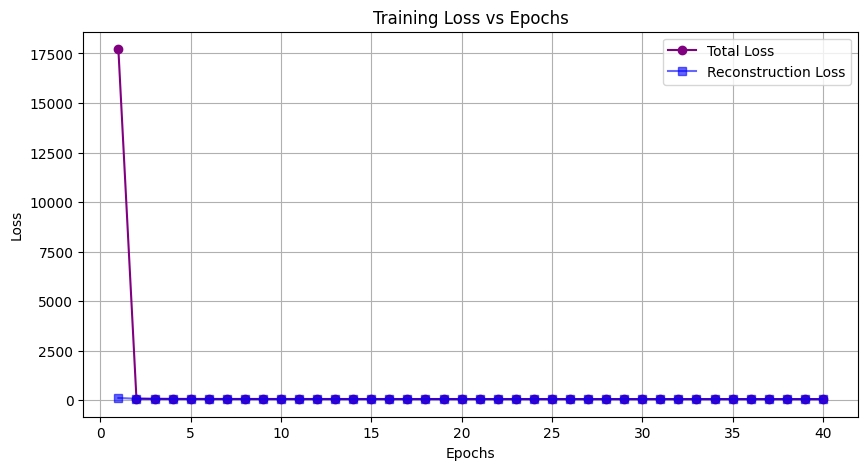

In [5]:
# Training Loop
epoch_losses = []
epoch_recons = []
epoch_klds = []

print(f"Starting Training for {num_epochs} Epochs with Beta={beta}...")
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_recon = 0
    train_kld = 0
    
    for batch_idx, (x, _) in enumerate(data_loader):
        x = x.to(device)
        
        # Forward pass
        recon_x, mean, log_var = model(x)
        loss, recon, kld = vae_loss(recon_x, x, mean, log_var, beta=beta)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        
        train_loss += loss.item()
        train_recon += recon.item()
        train_kld += kld.item()
        
    avg_loss = train_loss / len(data_loader.dataset)
    avg_recon = train_recon / len(data_loader.dataset)
    avg_kld = train_kld / len(data_loader.dataset)
    
    epoch_losses.append(avg_loss)
    epoch_recons.append(avg_recon)
    epoch_klds.append(avg_kld)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f} (Recon: {avg_recon:.4f}, KLD: {avg_kld:.4f})")

# Plot Loss vs Epochs
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), epoch_losses, marker='o', label='Total Loss', color='purple')
plt.plot(range(1, num_epochs+1), epoch_recons, marker='s', label='Reconstruction Loss', color='blue', alpha=0.6)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss vs Epochs')
plt.legend()
plt.grid(True)
plt.savefig('training_curves.png')
plt.show()


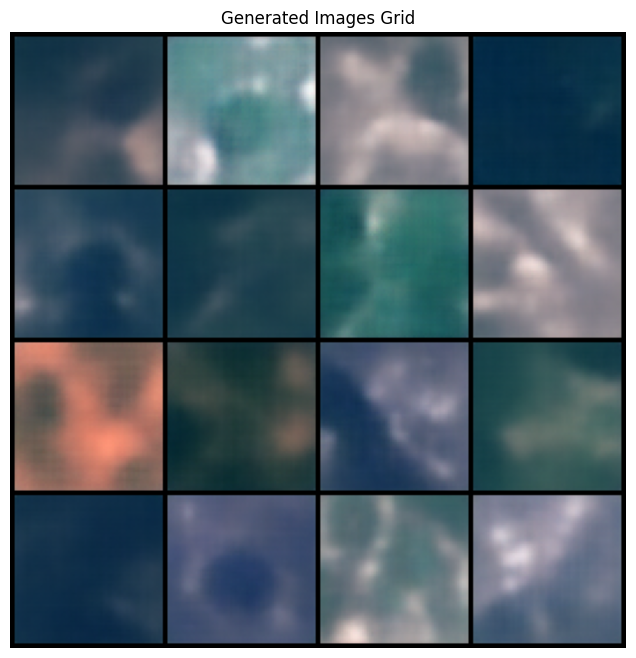

In [6]:
# Generate Grid of 16 Samples
model.eval()
with torch.no_grad():
    # Sample from standard normal distribution
    z = torch.randn(16, z_dim).to(device)
    generated_images = model.decode(z).cpu()
    
    # Plot samples
    plt.figure(figsize=(8, 8))
    plt.axis("off")
    plt.title("Generated Images Grid")
    plt.imshow(np.transpose(vutils.make_grid(generated_images, nrow=4, padding=2, normalize=True), (1, 2, 0)))
    plt.savefig('generated_samples.png')
    plt.show()


## Task 3: Latent Space Interpolation


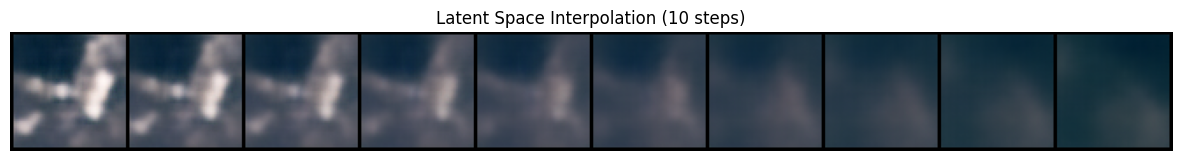

In [7]:
# Find indices for two distinct classes, e.g., 'Industrial' and 'Pasture'
if hasattr(dataset, 'class_to_idx'):
    class_to_idx = dataset.class_to_idx
elif hasattr(dataset, 'classes'):
    class_to_idx = {dataset.classes[i]: i for i in range(len(dataset.classes))}
else:
    class_to_idx = {c: i for i, c in enumerate(os.listdir(os.path.join(dataset_dir, "2750")))}

industrial_idx = class_to_idx.get('Industrial')
pasture_idx = class_to_idx.get('Pasture')

img_industrial = None
img_pasture = None

for img, label in dataset:
    if label == industrial_idx and img_industrial is None:
        img_industrial = img
    elif label == pasture_idx and img_pasture is None:
        img_pasture = img
    if img_industrial is not None and img_pasture is not None:
        break

if img_industrial is None or img_pasture is None:
    print("Distinct classes not found, using first two images")
    img_industrial, _ = dataset[0]
    img_pasture, _ = dataset[len(dataset)//2]
    
# Encode and interpolate
model.eval()
with torch.no_grad():
    x1 = img_industrial.unsqueeze(0).to(device)
    x2 = img_pasture.unsqueeze(0).to(device)
    
    z1, _ = model.encode(x1)
    z2, _ = model.encode(x2)

    # Linear Interpolation
    steps = 10
    alphas = torch.linspace(0, 1, steps).to(device)
    z_interp = torch.stack([(1 - a) * z1 + a * z2 for a in alphas]).squeeze(1)
    
    # Decode interpolated vectors
    decoded_interp = model.decode(z_interp).cpu()

# Plot Interpolation
plt.figure(figsize=(15, 3))
plt.title("Latent Space Interpolation (10 steps)")
plt.axis("off")
plt.imshow(np.transpose(vutils.make_grid(decoded_interp, nrow=10, padding=2, normalize=True), (1, 2, 0)))
plt.savefig('interpolation.png')
plt.show()


## Task 4: Semantic Vector Arithmetic


Gathering samples...


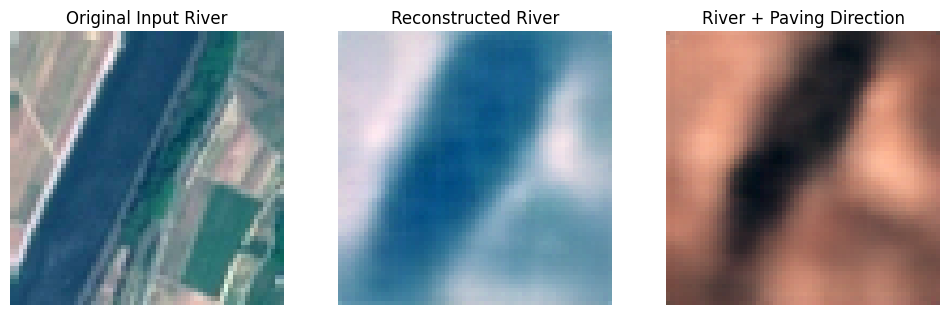

In [8]:
# Semantic Arithmetic: River + (Highway - Forest)
forest_idx = class_to_idx.get('Forest')
highway_idx = class_to_idx.get('Highway')
river_idx = class_to_idx.get('River')

def get_class_images(class_idx, limit=100):
    imgs = []
    for img, label in dataset:
        if label == class_idx:
            imgs.append(img)
            if len(imgs) >= limit:
                break
    if not imgs:
        return None
    return torch.stack(imgs)

print("Gathering samples...")
# Increased sample size for more robust average vectors
forest_imgs = get_class_images(forest_idx, limit=256)
highway_imgs = get_class_images(highway_idx, limit=256)
river_imgs = get_class_images(river_idx, limit=1)

if forest_imgs is not None and highway_imgs is not None and river_imgs is not None:
    model.eval()
    with torch.no_grad():
        # Encode batches
        z_forest, _ = model.encode(forest_imgs.to(device))
        z_forest_avg = z_forest.mean(dim=0, keepdim=True)
        
        z_highway, _ = model.encode(highway_imgs.to(device))
        z_highway_avg = z_highway.mean(dim=0, keepdim=True)
        
        paving_direction = z_highway_avg - z_forest_avg
        
        # Vector Arithmetic
        x_river = river_imgs[0].unsqueeze(0).to(device)
        z_river, _ = model.encode(x_river)
        
        # Let's apply pacing direction with a small scale explicitly if needed, but 1.0 is standard
        z_river_paved = z_river + 1.2 * paving_direction
        
        # Decode
        river_orig = model.decode(z_river).cpu()
        river_paved = model.decode(z_river_paved).cpu()
        
        # For comparison, let's also reconstruct the original to make sure it's accurate
        river_recon = model.decode(model.encode(x_river)[0]).cpu()

    # Plot
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    
    ax[0].imshow(np.transpose(vutils.make_grid(x_river.cpu(), padding=2, normalize=True), (1, 2, 0)))
    ax[0].set_title("Original Input River")
    ax[0].axis("off")
    
    ax[1].imshow(np.transpose(vutils.make_grid(river_recon, padding=2, normalize=True), (1, 2, 0)))
    ax[1].set_title("Reconstructed River")
    ax[1].axis("off")

    ax[2].imshow(np.transpose(vutils.make_grid(river_paved, padding=2, normalize=True), (1, 2, 0)))
    ax[2].set_title("River + Paving Direction")
    ax[2].axis("off")

    plt.savefig('semantic_arithmetic.png')
    plt.show()
else:
    print("Could not find required classes for semantic arithmetic.")
